In [1]:
import numpy as np
import pandas as pd
import  matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from scipy.stats import linregress, t, probplot, shapiro



In [2]:
import os

print(os.listdir())
print(os.listdir("../Data"))

['Practice1.ipynb', '.ipynb_checkpoints', 'Practice.ipynb']
['Salary_dataset.csv', '.ipynb_checkpoints', 'train.csv', 'raw_students.csv', 'test.csv']


In [3]:
df = pd.read_csv("../Data/Salary_dataset.csv")
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [4]:
df = pd.read_csv("../Data/Salary_dataset.csv", usecols=["YearsExperience","Salary"])
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [5]:
df.shape

(30, 2)

In [6]:
df.duplicated().any()

np.False_

Text(0, 0.5, 'SALARY')

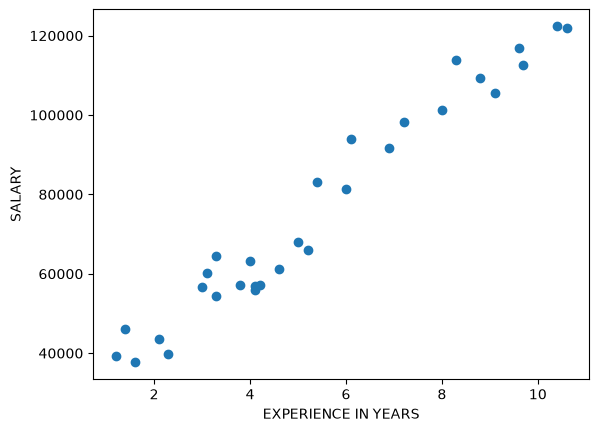

In [7]:
plt.scatter(df["YearsExperience"],df["Salary"])
plt.xlabel("EXPERIENCE IN YEARS")
plt.ylabel("SALARY")

In [8]:
x=df.iloc[:,0:1]
y=df.iloc[:,-1]

In [9]:
x

,YearsExperience
0,1.2
1,1.4
2,1.6
3,2.1
4,2.3
5,3.0
6,3.1
7,3.3
8,3.3
9,3.8


In [10]:
y

0      39344.0
1      46206.0
2      37732.0
3      43526.0
4      39892.0
5      56643.0
6      60151.0
7      54446.0
8      64446.0
9      57190.0
10     63219.0
11     55795.0
12     56958.0
13     57082.0
14     61112.0
15     67939.0
16     66030.0
17     83089.0
18     81364.0
19     93941.0
20     91739.0
21     98274.0
22    101303.0
23    113813.0
24    109432.0
25    105583.0
26    116970.0
27    112636.0
28    122392.0
29    121873.0
Name: Salary, dtype: float64

In [11]:
X_train,X_test, y_train, y_test= train_test_split(x,y,test_size=0.2,random_state=2)

In [12]:
X_train

,YearsExperience
23,8.3
6,3.1
3,2.1
20,6.9
5,3.0
27,9.7
12,4.1
4,2.3
10,4.0
16,5.2


In [13]:
y_train

23    113813.0
6      60151.0
3      43526.0
20     91739.0
5      56643.0
27    112636.0
12     56958.0
4      39892.0
10     63219.0
16     66030.0
28    122392.0
25    105583.0
17     83089.0
2      37732.0
7      54446.0
26    116970.0
24    109432.0
18     81364.0
11     55795.0
22    101303.0
29    121873.0
13     57082.0
15     67939.0
8      64446.0
Name: Salary, dtype: float64

In [14]:
lr= LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9569.59]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.344e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [15]:
X_test

,YearsExperience
1,1.4
0,1.2
14,4.6
9,3.8
21,7.2
19,6.1


In [16]:
y_test

1     46206.0
0     39344.0
14    61112.0
9     57190.0
21    98274.0
19    93941.0
Name: Salary, dtype: float64

In [17]:
lr.predict(X_test.iloc[0].values.reshape(1,1))

/home/as/Downloads/Repos/DailyTask/Task25/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([36834.63210301])

In [18]:
lr.predict(X_test.iloc[1].values.reshape(1,1))

/home/as/Downloads/Repos/DailyTask/Task25/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([34920.71472592])

Text(0, 0.5, 'SALARY')

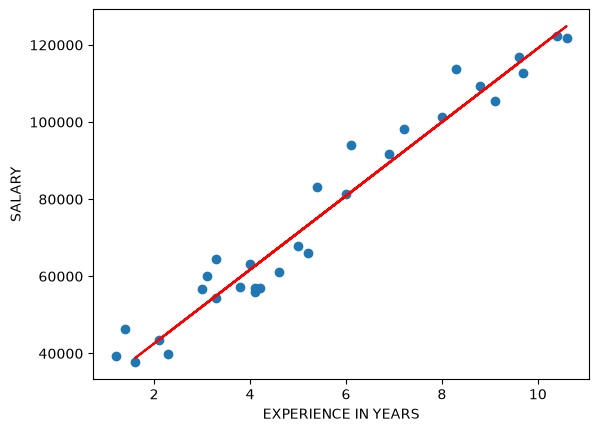

In [19]:
plt.scatter(df["YearsExperience"],df["Salary"])
plt.plot(X_train, lr.predict(X_train),color="red")
plt.xlabel("EXPERIENCE IN YEARS")
plt.ylabel("SALARY")

In [20]:
#slop:

m=lr.coef_
m

array([9569.58688543])

In [21]:
# intersept :

c= lr.intercept_
c

np.float64(23437.21046340505)

In [22]:
salary = m * 1.4 + c

salary

array([36834.63210301])